In [184]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [186]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

In [188]:
!pip install tensorflow

In [190]:
#SET PATHS
photos_dir = 'photos'  # Directory containing photo files
photos_json = 'photos.json'  # Path to JSON file
output_dir = 'preprocessed_data'  # Where to save processed data
os.makedirs(output_dir, exist_ok=True)

In [194]:
# Constants
IMG_SIZE = 128  # For CNN
MAX_IMAGES = 50000

# Load JSONL file (each line is a JSON object)
photos_data = []
with open(photos_json, 'r') as f:
    for line in f:
        try:
            photos_data.append(json.loads(line.strip()))
        except json.JSONDecodeError as e:
            print(f'Error parsing line: {e}')
            continue

# Convert to DataFrame
photos_df = pd.DataFrame(photos_data)
photos_df = photos_df.sample(n=20000, random_state=42).reset_index(drop=True)

print('Sampled DataFrame shape:', photos_df.shape)
print(photos_df.head())


Sampled DataFrame shape: (20000, 4)
                 photo_id             business_id              caption  label
0  k_PSngRS22mSA1MypwrjPg  DzzVSYXadZ1_XgfGz_Loyw  Chocolate Croissant   food
1  D_94KivwVgitkzFIgE_KcQ  Xdzir62WKlSzeu4PMQtlBA                        food
2  Hf39P7_G_eRCqfVwvMDV6g  z0HzwNBmx_BgdiYI4hLk3g    Happy Anniversary  drink
3  agxl4sABeRXwjLL506KMrQ  HzRSWmNxcEVQGrr1tun25w       Frozen Puccino   food
4  7cZ0MREN2TwAAX4nnirQlA  aj0urA2r2WlqZKufeB5dpw  Double Cheeseburger   food


In [196]:
# Label distribution
print("\nLabel distribution:\n", photos_df['label'].value_counts())

# Check missing values and caption lengths
print("\nMissing captions:", photos_df['caption'].isnull().sum())
print("\nCaption length stats:\n", photos_df['caption'].str.len().describe())


Label distribution:
 label
food       10877
inside      5550
outside     1850
drink       1550
menu         173
Name: count, dtype: int64

Missing captions: 0

Caption length stats:
 count    20000.000000
mean        14.999000
std         24.376036
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        140.000000
Name: caption, dtype: float64


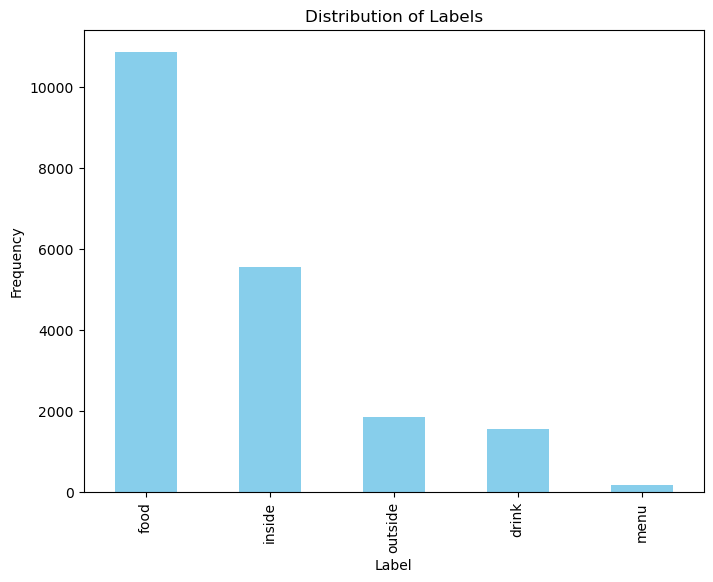

In [198]:
# Plot label distribution
import matplotlib.pyplot as plt

label_counts = photos_df['label'].value_counts()
plt.figure(figsize=(8, 6))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

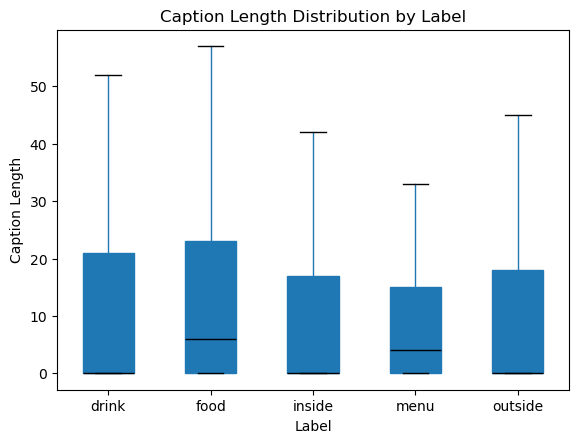

In [200]:
# Caption length boxplot
photos_df['caption_length'] = photos_df['caption'].str.len()
plt.figure(figsize=(10, 6))
photos_df.boxplot(column='caption_length', by='label', grid=False, showfliers=False, patch_artist=True, medianprops={'color': 'black'})
plt.title('Caption Length Distribution by Label')
plt.suptitle('')
plt.xlabel('Label')
plt.ylabel('Caption Length')
plt.show()

In [202]:
# Unique businesses by label
business_by_label = photos_df.groupby('label')['business_id'].nunique()
print("\nUnique businesses per label:\n", business_by_label)


Unique businesses per label:
 label
drink      1382
food       7458
inside     4239
menu        166
outside    1559
Name: business_id, dtype: int64


In [204]:
# Encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
photos_df['label'] = le.fit_transform(photos_df['label'])

In [206]:
# Process images
images = []
labels = []
skipped_count = 0
total = min(MAX_IMAGES, len(photos_df))

print(f"\nTotal images to process: {total}")

for i, row in enumerate(photos_df.itertuples(index=False)):
    if i >= MAX_IMAGES:
        break

    img_path = os.path.join(photos_dir, f"{row.photo_id}.jpg")  #  use photo_id

    try:
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
            img_array = np.asarray(img, dtype=np.float32) / 255.0  # Normalize
            images.append(img_array)
            labels.append(row.label)
    except Exception as e:
        skipped_count += 1
        print(f"Failed to process {img_path}: {e}")

    if i % (total // 20 or 1) == 0 or i == total - 1:
        percent = (i + 1) / total * 100
        print(f"Progress: {percent:.1f}% ({i + 1}/{total})", end='\r')

print(f"\n\nFinished processing {len(images)} images.")
print(f"Skipped {skipped_count} corrupted/unreadable images.")


Total images to process: 20000
Failed to process photos\1MOGQBWogR8oJr1WgERi9g.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\1MOGQBWogR8oJr1WgERi9g.jpg'
Failed to process photos\pW1IPuTdLIUB61goirbXaA.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\pW1IPuTdLIUB61goirbXaA.jpg'
Failed to process photos\CBxmBYD_5CXIL_F-2PDqmA.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\CBxmBYD_5CXIL_F-2PDqmA.jpg'
Failed to process photos\W94rrCn0O5K1lkfD26m4tw.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\W94rrCn0O5K1lkfD26m4tw.jpg'
Failed to process photos\7xcWPjcE4mxoQ1AjvvKJZg.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\7xcWPjcE4mxoQ1AjvvKJZg.jpg'
Failed to process photos\JZZ716oX6_MqH6L_Mk

In [208]:
test_path = os.path.join(photos_dir, f"{photos_df.iloc[0].photo_id}.jpg")
print("Test path:", test_path)

try:
    with Image.open(test_path) as img:
        img = img.convert('RGB')
        img = img.resize((64, 64))
        img_array = np.asarray(img, dtype=np.float32) / 255.0
        print("Image shape:", img_array.shape)
except Exception as e:
    print("Error:", e)


Test path: photos\k_PSngRS22mSA1MypwrjPg.jpg
Image shape: (64, 64, 3)


In [210]:
# 1. Flatten image arrays
X = np.array(images).reshape(len(images), -1)  # (num_samples, 64*64*3)
y = np.array(labels)


In [212]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


In [214]:
#create sample data if you're just testing
import numpy as np
X = np.random.rand(100, 4)  # Create 100 samples with 4 features
y = np.random.randint(0, 2, 100)  # Binary target variable

# Now split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [216]:
# 3. Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [218]:
# 4. Predict and evaluate
y_pred = knn.predict(X_test)
